# **The RM-D2 Plate Formulation**

This notebook introduces a 2-parameter rotation-free Reissner-Mindlin plate formulation (**RM-D2**). The goal is to obtain a shear-locking free formulation through the use of displacement-only DOFs, as well as reduce the number of node DOFs at the cost of higher continuity requirements.

The element uses a Helmholz-type decomposition to represent the rotational fields, using only **two scalar unknowns per control point**:

- $w_b$, a bending displacement potential,
- $\psi$, a scalar potential whose curl carries the solenoidal rotation contribution.

The formulation is based on the Timoshenko beam formulation proposed by Kiendl et al. in [2].

## **RM-D2 Among Existing Formulations**

| Formulation | DOFs | Expected behaviour |
|---|---|---|
| **`KL-1`** (standard) | $w$ | Neglects shear deformation; expected to fail at low slenderness |
| **`RM-3`** (standard) | $w, \varphi_x, \varphi_y$ | Suffers from shear locking; expected to fail at high slenderness |
| **`RM-D3`** [1] | $w_b, w_{s1}, w_{s2}$ | Expected to work across the full slenderness range. |
| **`RM-D2`** [2]\* (**proposed here**) | $w_b, \psi$ | 2-field Helmholz-type decomposition; expected to work across the full slenderness range |
| **`RM-D-1`** [3] | $w_b$ | Shear deformable, but fails to capture solenoidal rotations; expected to fail at low slenderness |

#### **References**

[1] Oesterle, B., Ramm, E., & Bischoff, M. (2016). A shear deformable, rotation-free isogeometric shell formulation. *Computer Methods in Applied Mechanics and Engineering*, 307, 235–255. https://doi.org/10.1016/j.cma.2016.04.015.

[2] Kiendl, J., Auricchio, F., Hughes, T. J. R., & Reali, A. (2015). Single-variable formulations and isogeometric discretizations for shear deformable beams. *Computer Methods in Applied Mechanics and Engineering*, 284, 988–1004. https://doi.org/10.1016/j.cma.2014.11.011.

[3] Tran, L. V., Dao, T. N., & Van Do, V. N. (2026). Isogeometric implementation of a single-variable shear deformable plate theory. *Finite Elements in Analysis and Design*, 255, 104502. https://doi.org/10.1016/j.finel.2025.104502


In [56]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

import pyck as ck

FORMULATIONS = {
    "KL-1": ck.PlateKirchhoffLove1p,
    "RM-3": ck.PlateReissnerMindlin3p,
    "RM-D3": ck.PlateReissnerMindlinDispl3p,
    "RM-D2": ck.PlateReissnerMindlinDispl2p,
    "RM-D1": ck.PlateReissnerMindlin1p,
}

## **Derivation**

### **Decomposition of the Transverse Displacement**

The total transverse displacement is split into its bending and shear contributions:

$$
w = w_b + w_s,
$$

The gradients $\nabla{w_b}$ and $\nabla{w_s}$ are irrotational by construction, and therefore cannot represent the full rotation and shear strain fields on their own. To span the complete space of vector fields, a solenoidal contribution must be added via a scalar potential $\psi$:

$$\begin{aligned}
\boldsymbol\varphi &= -\nabla w_b + \nabla\times\psi \\
\boldsymbol\gamma &= \nabla w_s + \nabla\times\psi
\end{aligned}$$

### **Static Condensation of the Shear Displacement**

The shear transverse displacement can be statically condensed in favor of the bending displacement:

$$
w_s = - \frac{K_b}{K_s} \nabla^2 w_b
$$

where $K_b$ and $K_s$ represent the bending and shear stiffnesses.

### **Resulting Strain Fields**

Substituting back, the **bending strain** $\boldsymbol\kappa$ and the **transverse shear strain** $\boldsymbol\gamma$ are expressed purely in terms of $\{ w_b, \psi \}$:

$$\begin{aligned}
\boldsymbol\kappa &= \mathbf{L} ( -\nabla w_b + \nabla\times\psi ) \\
\boldsymbol\gamma &= -\nabla\left(\frac{K_b}{K_s}\nabla^2 w_b\right) + \nabla\times\psi
\end{aligned}$$

The result is a 2-parameter shear-deformable plate formulation, based on Reissner–Mindlin plate theory and discretized with isogeometric analysis to satisfy the $C^2$ continuity requirement.

### **The Solenoidal Mode**

The key observation is that a two-dimensional rotation or shear vector field is not generally a gradient field. A single displacement parameter formulation can recover only the irrotational part. This is why a one-parameter shear-deformable plate such as `RM-D1` can be too restrictive near clamped boundaries, corners, and other regions where the rotation field contains a localized solenoidal component.

RM-D2 keeps the formulation rotation-free, but augments the bending potential with one scalar field $\psi$. Its curl,

$$
\nabla \times \psi = \begin{bmatrix}
\partial \psi / \partial y \\
-\partial \psi / \partial x
\end{bmatrix},
$$

adds exactly the missing divergence-free part of the rotation field. In that sense, RM-D2 sits between `RM-D1` and `RM-D3`: it is richer than a single-field rotation-free model, but cheaper than a three-field split-displacement model.


## **Postprocessing Helpers**

Two scalar quantities are used throughout the benchmark notebooks:
the reconstructed transverse displacement, and the strain energy.

### **Maximum Displacement**

The displacement field is recovered from the element displacement shape matrix,

$$
w(\boldsymbol{x}) = \mathbf{N}_w(\boldsymbol{x})\,\hat{\mathbf{u}},
$$

where $\hat{\mathbf{u}}$ contains only the physical unknowns, excluding Lagrange multiplier DOFs.

### **Strain and External Energy**

$$
U = \tfrac{1}{2}\hat{\mathbf{u}}^{T}\mathbf{K}\hat{\mathbf{u}}, \quad
W = \tfrac{1}{2}\,\mathbf{F}^{T}\hat{\mathbf{u}}.
$$

For a linear static problem at equilibrium the two are equivalent.

For RM-D2 we also recover the internal fields $w_b$ and $\psi$ directly from the interleaved solution vector. From $\psi$ we can compute the solenoidal rotation contribution $\nabla\times\psi$, which is the field that distinguishes this formulation from a pure-gradient rotation-free plate.


In [57]:
def max_displacement(problem, solution, n_eval=81):
    """Compute the maximum reconstructed transverse displacement."""
    plate = problem.patches[0]
    element = problem.element
    u = np.asarray(solution)[:problem.num_physical_dofs]

    grid = np.linspace(0.0, 1.0, n_eval)
    uu, vv = np.meshgrid(grid, grid, indexing="xy")
    pts = np.column_stack([uu.ravel(), vv.ravel()])

    shape = ck.eval_shape_at(plate, pts, order=2)
    Nw = element._cpp_object.displacement_shape_matrix(shape)
    w = Nw @ u

    return float(np.max(np.abs(w)))


def center_displacement(problem, solution):
    """Compute the reconstructed transverse displacement at the plate center."""
    plate = problem.patches[0]
    element = problem.element
    u = np.asarray(solution)[:problem.num_physical_dofs]

    shape = ck.eval_shape_at(plate, np.array([[0.5, 0.5]]), order=2)
    Nw = element._cpp_object.displacement_shape_matrix(shape)
    return float(abs((Nw @ u)[0]))


def strain_energy(solution, K):
    """Compute the strain energy from the solution and stiffness matrix."""
    num_phys = K.shape[0]
    u_phys = solution[:num_phys]
    return 0.5 * np.dot(u_phys, K @ u_phys)


def external_work_energy(solution, F):
    """Compute the energy from the physical external load vector."""
    u_phys = np.asarray(solution)[:F.shape[0]]
    return 0.5 * float(np.dot(F, u_phys))


## **Worked Example: Clamped Square Plate Under Uniform Load**

To make the formulation tangible, we solve a single representative problem with RM-D2: a fully clamped, moderately thick square plate ($L/h = 4$) under a uniform downward pressure. Clamped edges are enforced with Lagrange multipliers, and the patch uses a $C^2$ B-spline basis of degree $p = 3$.

The example is intentionally compact: a moderately thick plate is the regime where the solenoidal correction $\nabla\times\psi$ matters most, so it makes the role of the second unknown easy to see in the plots that follow. The full convergence and slenderness sweeps live in the companion notebooks.


In [58]:
# Geometry and material -----------------------------------------------------
L, W = 1.0, 1.0
SLENDERNESS = 4.0          # moderately thick plate (solenoidal regime)
t = L / SLENDERNESS
E, nu = 10.92, 0.3
f0 = -10.0                 # uniform downward load

def uniform_load(pts):
    return f0 * np.ones(pts.shape[0])

# Discretization ------------------------------------------------------------
PDEG = 3
NBASIS = 32

material = ck.material.create_plane_stress_2d(E, nu, t)
patch = ck.geometry.create_rectangle(nu=NBASIS, nv=NBASIS, deg=PDEG, l=L, w=W)
gauss2d = ck.GaussLegendre(PDEG + 1, dim=2)
gauss1d = ck.GaussLegendre(PDEG + 1, dim=1)

element = FORMULATIONS["RM-D2"](material)
problem = ck.LinearElasticProblem([patch], element, gauss2d)

# Apply distributed load before assembly ------------------------------------
load_cond = ck.conditions.create_load_condition(
    patch=patch, load_fn=uniform_load, quadrature=gauss2d
)
problem.add_condition(load_cond)
K, F = problem.assemble()

# Clamp all four edges with Lagrange multipliers ----------------------------
for side in ("u0", "u1", "v0", "v1"):
    problem.add_condition(
        ck.LagrangeMultiplierCondition(
            boundary=patch.boundary(side),
            quadrature=gauss1d,
            w_bar=0.0, phi_n_bar=0.0, phi_s_bar=0.0,
        )
    )

# Solve & Postprocessing ----------------------------------------------------
u = ck.solve(problem)
w_max = max_displacement(problem, u)
w_center = center_displacement(problem, u)
U = strain_energy(u, K)
print(f"Mesh:           p={PDEG}, {NBASIS}x{NBASIS} basis functions, "
      f"{problem.num_physical_dofs} physical DOFs")
print(f"Slenderness:    L/h = {SLENDERNESS:g}")
print(f"Center |w|:     {w_center:.6e}")
print(f"Max |w|:        {w_max:.6e}")
print(f"Strain energy:  {U:.6e}")


Mesh:           p=3, 32x32 basis functions, 2048 physical DOFs
Slenderness:    L/h = 4
Center |w|:     1.699234e+00
Max |w|:        1.699234e+00
Strain energy:  3.335089e+00


### **Deformed Plate**

The reconstructed transverse displacement is split into the total field $w$, the bending field $w_b$, and the recovered shear contribution $w-w_b$. Plotting the three surfaces side by side makes the internal RM-D2 decomposition visible: most of the deflection is carried by the bending field, while the shear part is the thickness-dependent correction that becomes relevant in the moderately thick regime.


In [ ]:
# Grid details --------------------------------------------------------------
n_eval = 121
grid = np.linspace(0.0, 1.0, n_eval)
uu, vv = np.meshgrid(grid, grid, indexing="xy")
X, Y = uu * L, vv * W
pts = np.column_stack([uu.ravel(), vv.ravel()])

# Shape functions and physical coordinates ----------------------------------
shape = ck.eval_shape_at(patch, pts, order=2)
u_phys = np.asarray(u)[:problem.num_physical_dofs]

# Transverse displacements: w, wb, ws -------------------------------------
Nw = element._cpp_object.displacement_shape_matrix(shape)
w_field = np.asarray(Nw @ u_phys).reshape(uu.shape)

wb_coeff = u_phys[0::2]
wb_field = np.asarray(shape[0] @ wb_coeff).reshape(uu.shape)
wb_x = np.asarray(shape[1] @ wb_coeff).reshape(uu.shape)
wb_y = np.asarray(shape[2] @ wb_coeff).reshape(uu.shape)

ws_field = w_field - wb_field
ws_y, ws_x = np.gradient(ws_field, Y[:, 0], X[0, :], edge_order=2)

# Potential field: psi -----------------------------------------------------
psi_coeff = u_phys[1::2]
psi_field = np.asarray(shape[0] @ psi_coeff).reshape(uu.shape)
psi_x = np.asarray(shape[1] @ psi_coeff).reshape(uu.shape)
psi_y = np.asarray(shape[2] @ psi_coeff).reshape(uu.shape)

# Solenoidal mode: curl(psi) -----------------------------------------------
solenoidal_rot_x = psi_y
solenoidal_rot_y = -psi_x
solenoidal_rot_norm = np.sqrt(solenoidal_rot_x**2 + solenoidal_rot_y**2)

# Rotation decomposition: -grad(wb) + curl(psi) ----------------------------
curl_free_rot_x = -wb_x
curl_free_rot_y = -wb_y
curl_free_rot_norm = np.sqrt(curl_free_rot_x**2 + curl_free_rot_y**2)

corrected_rot_x = curl_free_rot_x + solenoidal_rot_x
corrected_rot_y = curl_free_rot_y + solenoidal_rot_y
corrected_rot_norm = np.sqrt(corrected_rot_x**2 + corrected_rot_y**2)

# Shear strain decomposition: grad(ws) + curl(psi) -------------------------
curl_free_shear_x = ws_x
curl_free_shear_y = ws_y
curl_free_shear_norm = np.sqrt(curl_free_shear_x**2 + curl_free_shear_y**2)

corrected_shear_x = curl_free_shear_x + solenoidal_rot_x
corrected_shear_y = curl_free_shear_y + solenoidal_rot_y
corrected_shear_norm = np.sqrt(corrected_shear_x**2 + corrected_shear_y**2)

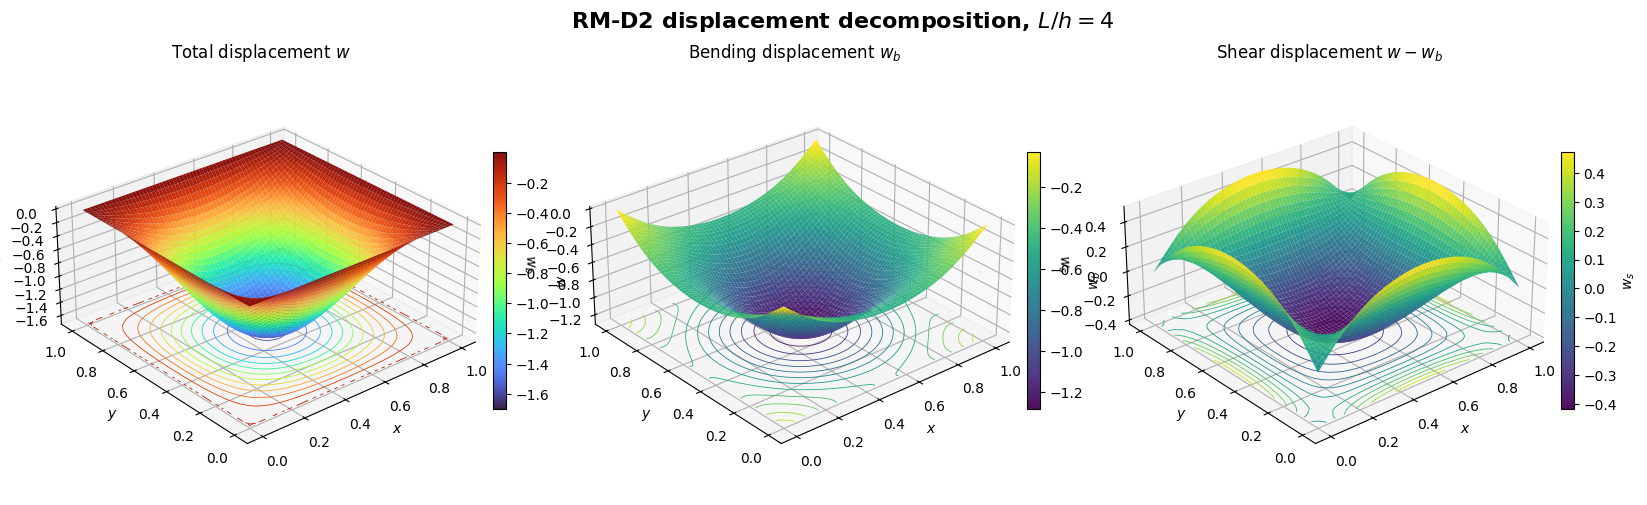

In [60]:
# Plot transverse displacement fields --------------------------------------
fig = plt.figure(figsize=(16, 5), constrained_layout=True)

surface_fields = [
    (w_field, r"Total displacement $w$", r"$w$", cm.turbo),
    (wb_field, r"Bending displacement $w_b$", r"$w_b$", cm.viridis),
    (ws_field, r"Shear displacement $w-w_b$", r"$w_s$", cm.viridis),
]

for i, (field, title, label, cmap) in enumerate(surface_fields, start=1):
    ax = fig.add_subplot(1, 3, i, projection="3d")
    surf = ax.plot_surface(
        X,
        Y,
        field,
        cmap=cmap,
        linewidth=0,
        antialiased=True,
        rstride=2,
        cstride=2,
        alpha=0.95,
    )
    ax.contour(
        X,
        Y,
        field,
        zdir="z",
        offset=float(np.min(field)),
        cmap=cmap,
        levels=14,
        linewidths=0.6,
    )
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.set_zlabel(label)
    ax.set_title(title)
    ax.view_init(elev=28, azim=-130)
    ax.set_box_aspect((1.0, 1.0, 0.45))
    fig.colorbar(surf, ax=ax, shrink=0.58, pad=0.04, label=label)

fig.suptitle(
    rf"RM-D2 displacement decomposition, $L/h={SLENDERNESS:g}$", 
    fontsize=16, fontweight="bold"
    )
plt.show()

### **Scalar Potential and Solenoidal Rotation**

The second RM-D2 unknown is the scalar potential $\psi$. By itself, $\psi$ is not a rotation component; it is a potential field whose spatial derivatives generate the solenoidal part of the rotation and shear fields. With our sign convention,

$$
\nabla\times\psi = \begin{bmatrix}
\partial\psi/\partial y \\
-\partial\psi/\partial x
\end{bmatrix}.
$$

The left plot shows the recovered scalar potential $\psi$ from the RM-D2 solution. The right plot shows the vector field produced by its curl: the color is $|\nabla\times\psi|$, and the arrows indicate its direction. This is the localized rotational content that a pure gradient field cannot provide, and it is the extra mode that distinguishes RM-D2 from a single-parameter rotation-free model.


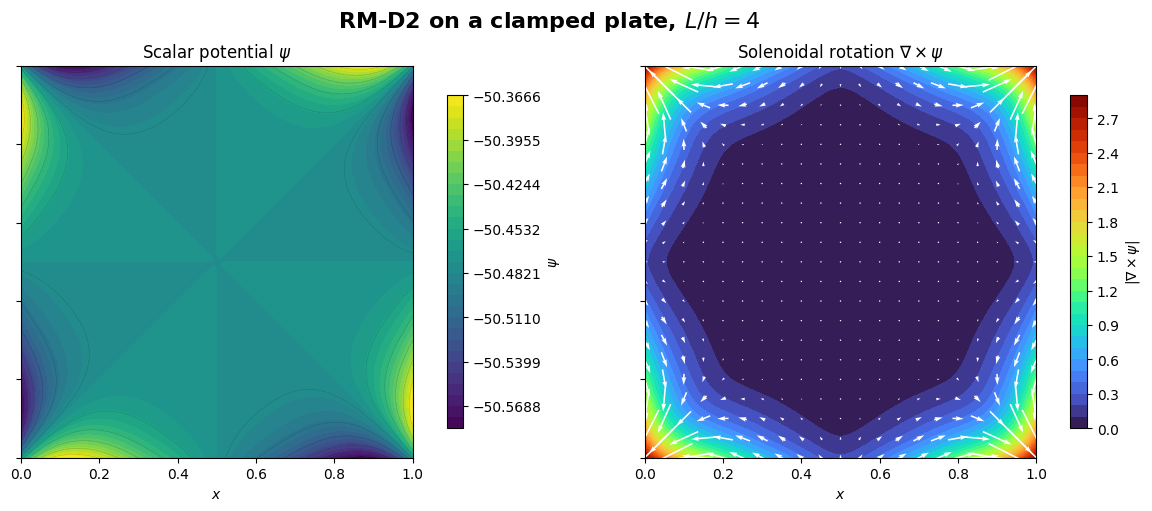

In [ ]:
# Plot scalar potential psi and solenoidal rotation -------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

ax = axes[0]
psi_max, psi_min = float(np.max(psi_field)), float(np.min(psi_field))
psi_levels = np.linspace(psi_min, psi_max, 31)
cf_psi = ax.contourf(X, Y, psi_field, levels=psi_levels, cmap="viridis")
ax.contour(X, Y, psi_field, levels=12, colors="k", linewidths=0.3, alpha=0.3)
ax.set_aspect("equal")
ax.set_xlabel(r"$x$")
ax.set_yticklabels([])
ax.set_title(r"Scalar potential $\psi$")
fig.colorbar(cf_psi, ax=ax, shrink=0.85, label=r"$\psi$")

ax = axes[1]
cf_rot = ax.contourf(X, Y, solenoidal_rot_norm, levels=31, cmap="turbo")
skip = 6
ax.quiver(
    X[::skip, ::skip],
    Y[::skip, ::skip],
    solenoidal_rot_x[::skip, ::skip],
    solenoidal_rot_y[::skip, ::skip],
    color="white",
    pivot="mid",
    scale_units="xy",
    width=0.004,
)
ax.set_aspect("equal")
ax.set_xlabel(r"$x$")
ax.set_yticklabels([])
ax.set_title(r"Solenoidal rotation $\nabla\times\psi$")
fig.colorbar(cf_rot, ax=ax, shrink=0.85, label=r"$|\nabla\times\psi|$")

fig.suptitle(
    rf"RM-D2 on a clamped plate, $L/h={SLENDERNESS:g}$",
    fontsize=16, fontweight="bold"
)
plt.show()

### **What the Single-Parameter Model Misses**

If only $w_b$ and $w_s$ are available, the bending rotation and shear strain are restricted to gradient fields:

$$
\boldsymbol\varphi_{\mathrm{cf}} = -\nabla w_b, \qquad
\boldsymbol\gamma_{\mathrm{cf}} = \nabla w_s.
$$

These are the curl-free fields available to a single-parameter rotation-free model. RM-D2 adds the same solenoidal correction carried by $\psi$ to both fields:

$$
\boldsymbol\varphi_{\mathrm{RM-D2}} = -\nabla w_b + \nabla\times\psi, \qquad
\boldsymbol\gamma_{\mathrm{RM-D2}} = \nabla w_s + \nabla\times\psi.
$$

The plots below compare the curl-free fields against the corrected RM-D2 fields recovered from the same solution. This makes visible what the single-parameter model is missing.


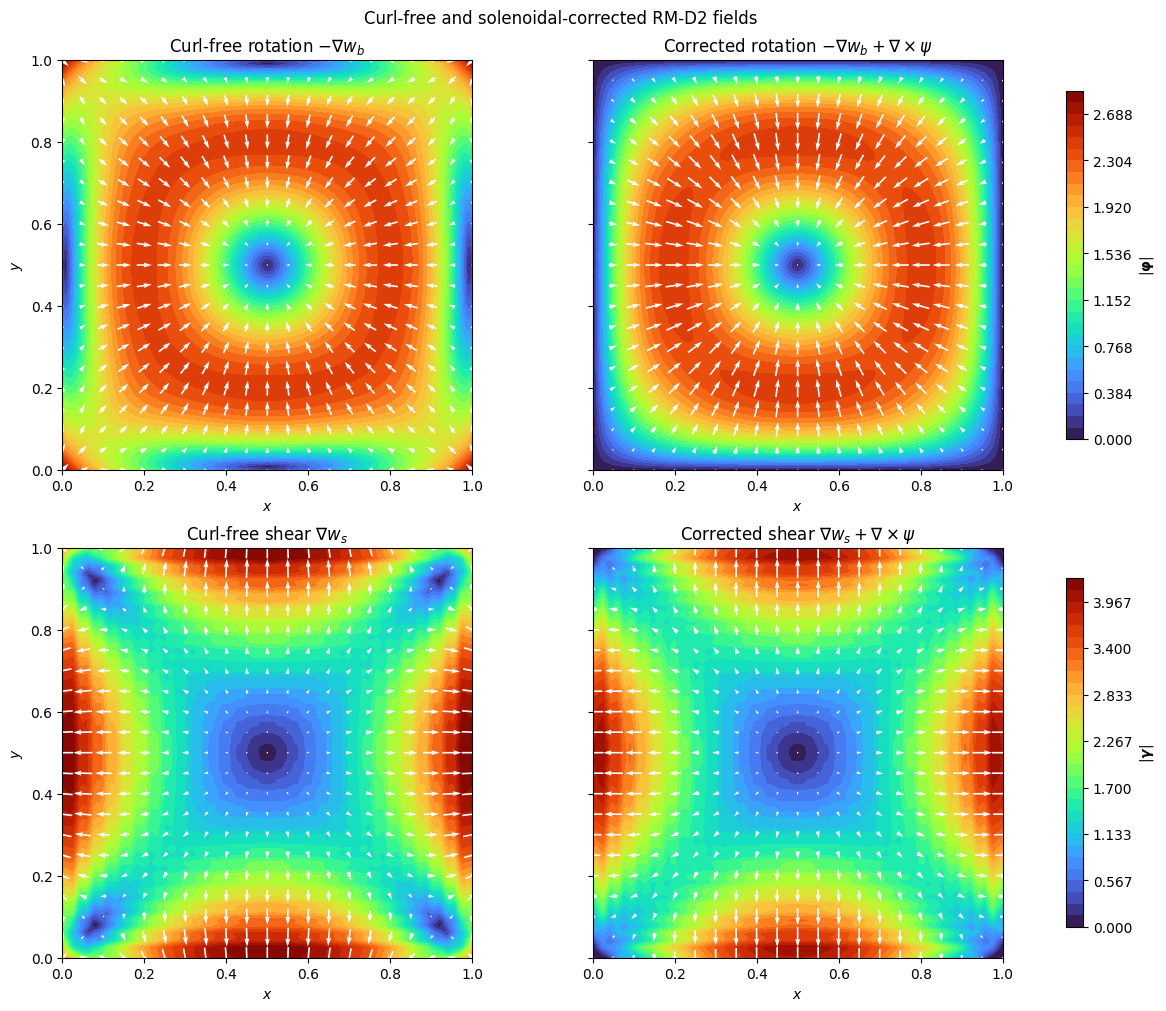

In [72]:
# Rotation fields (irrotational and complete) plots --------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

rotation_norm_max = max(
    float(np.max(curl_free_rot_norm)),
    float(np.max(corrected_rot_norm)),
)
shear_norm_max = max(
    float(np.max(curl_free_shear_norm)),
    float(np.max(corrected_shear_norm)),
)
rotation_levels = np.linspace(0.0, rotation_norm_max, 31)
shear_levels = np.linspace(0.0, shear_norm_max, 31)
skip = 6

field_rows = [
    (
        axes[0],
        rotation_levels,
        r"$|\boldsymbol{\varphi}|$",
        [
            (
                curl_free_rot_norm,
                curl_free_rot_x,
                curl_free_rot_y,
                r"Curl-free rotation $-\nabla w_b$",
            ),
            (
                corrected_rot_norm,
                corrected_rot_x,
                corrected_rot_y,
                r"Corrected rotation $-\nabla w_b + \nabla\times\psi$",
            ),
        ],
    ),
    (
        axes[1],
        shear_levels,
        r"$|\boldsymbol{\gamma}|$",
        [
            (
                curl_free_shear_norm,
                curl_free_shear_x,
                curl_free_shear_y,
                r"Curl-free shear $\nabla w_s$",
            ),
            (
                corrected_shear_norm,
                corrected_shear_x,
                corrected_shear_y,
                r"Corrected shear $\nabla w_s + \nabla\times\psi$",
            ),
        ],
    ),
]

for ax_row, levels, colorbar_label, fields in field_rows:
    row_cf = None
    for ax, (norm, field_x, field_y, title) in zip(ax_row, fields):
        row_cf = ax.contourf(X, Y, norm, levels=levels, cmap="turbo")
        ax.quiver(
            X[::skip, ::skip],
            Y[::skip, ::skip],
            field_x[::skip, ::skip],
            field_y[::skip, ::skip],
            color="white",
            pivot="mid",
            scale_units="xy",
            width=0.004,
        )
        ax.set_aspect("equal")
        ax.set_xlabel(r"$x$")
        ax.set_title(title)

    ax_row[0].set_ylabel(r"$y$")
    ax_row[1].set_yticklabels([])
    fig.colorbar(row_cf, ax=ax_row, shrink=0.85, label=colorbar_label)

fig.suptitle(r"Curl-free and solenoidal-corrected RM-D2 fields")
plt.show()


---

## **What is Next**

1. [Case 1: Clamped BCs, Uniform Load](2_clamped_uniform_load.ipynb)
2. [Case 3: Cantilever Plate Beam Benchmark](3_cantilever_beam.ipynb)
3. [Case 4: Manufactured Load](4_manufactured_load.ipynb)
